<a href="https://colab.research.google.com/github/sameerkarur/Data_science/blob/main/03_IITK_AIML_Core_Machine_Learning/projects/Creating_Cohorts_of_Songs/Creating_Cohorts_of_Songs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating Cohorts of Songs - EDA & Cluster Analysis

**Course-end Project 1 | IITK AIML Core: Machine Learning**

**Problem Objective:** Perform exploratory data analysis and cluster analysis on Rolling Stones Spotify tracks to create cohorts of similar songs and understand the factors that define each cohort.

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
df = pd.read_csv('datasets/rolling_stones_spotify.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names: {df.columns.tolist()}')
df.head(10)

Dataset shape: (1610, 18)

Column names: ['Unnamed: 0', 'name', 'album', 'release_date', 'track_number', 'id', 'uri', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']


,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.4630,0.9930,0.9960,0.9320,-12.9130,0.1100,118.0010,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.3260,0.9650,0.2330,0.9610,-4.8030,0.0759,131.4550,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.3860,0.9690,0.4000,0.9560,-4.9360,0.1150,130.0660,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.3690,0.9850,0.0001,0.8950,-5.5350,0.1930,132.9940,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.3030,0.9690,0.0559,0.9660,-5.0980,0.0930,130.5330,0.2060,32,305106
5,5,Monkey Man - Live,Licked Live In NYC,2022-06-10,6,3ixZ1NQk5sqvBZgWeIdiqr,spotify:track:3ixZ1NQk5sqvBZgWeIdiqr,0.2750,0.3400,0.9560,0.1250,0.7410,-5.5390,0.0915,101.6280,0.1250,31,244293
6,6,Angie - Live,Licked Live In NYC,2022-06-10,7,3R1Vq1RS6mWNSD2oni6jNf,spotify:track:3R1Vq1RS6mWNSD2oni6jNf,0.5610,0.2620,0.8100,0.0000,0.9720,-6.8510,0.0969,77.5200,0.3940,31,245506
7,7,Let It Bleed - Live,Licked Live In NYC,2022-06-10,8,0TGmW5dvuocb0QUMPsj31R,spotify:track:0TGmW5dvuocb0QUMPsj31R,0.3170,0.4130,0.9710,0.0003,0.9930,-5.5090,0.0873,128.9580,0.4840,30,313586
8,8,Midnight Rambler - Live,Licked Live In NYC,2022-06-10,9,643LFQHx7UKat9u6UlwPBr,spotify:track:643LFQHx7UKat9u6UlwPBr,0.4160,0.2680,0.9420,0.0408,0.9590,-6.0180,0.1190,139.4520,0.2850,30,781173
9,9,Tumbling Dice - Live,Licked Live In NYC,2022-06-10,10,5NMRgeO81hNY5nEEY54XtK,spotify:track:5NMRgeO81hNY5nEEY54XtK,0.4010,0.3100,0.9440,0.0752,0.9740,-5.0740,0.1280,119.7820,0.1880,29,333413


## 2. Initial Data Inspection & Cleaning

Examine duplicates, missing values, irrelevant entries, and outliers.

### 2.1 Structure & Missing Values

In [3]:
# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns or df.columns[0] == '':
    first = df.columns[0]
    if first.startswith('Unnamed') or first == '':
        df = df.drop(columns=[first])

print('Data types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum())
print(f'\nTotal missing: {df.isna().sum().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'Duplicate Spotify IDs: {df["id"].duplicated().sum()}')

Data types:
name                    str
album                   str
release_date            str
track_number          int64
id                      str
uri                     str
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
valence             float64
popularity            int64
duration_ms           int64
dtype: object

Missing values:
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

Total missing: 0

Duplicate rows: 0
Duplicate Spotify IDs: 0


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,1610,954,Honky Tonk Women - Live,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album,1610,90,Voodoo Lounge Uncut (Live),56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,1610,57,1972-05-12,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_number,1610.0000,NaN,NaN,NaN,8.6137,6.5602,1.0000,4.0000,7.0000,11.0000,47.0000
id,1610,1610,2IEkywLJ4ykbhi1yRQvmsT,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uri,1610,1610,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acousticness,1610.0000,NaN,NaN,NaN,0.2505,0.2274,0.0000,0.0583,0.1830,0.4038,0.9940
danceability,1610.0000,NaN,NaN,NaN,0.4689,0.1418,0.1040,0.3622,0.4580,0.5780,0.8870
energy,1610.0000,NaN,NaN,NaN,0.7924,0.1799,0.1410,0.6740,0.8485,0.9450,0.9990
instrumentalness,1610.0000,NaN,NaN,NaN,0.1642,0.2762,0.0000,0.0002,0.0138,0.1790,0.9960


### 2.2 Data Cleaning

In [5]:
# Parse dates and engineer year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['duration_min'] = df['duration_ms'] / 60000

# Strip whitespace from text columns
for col in ['name', 'album', 'id', 'uri']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Drop exact duplicates if any
before = len(df)
df = df.drop_duplicates()
print(f'Rows after dropping duplicates: {len(df)} (removed {before - len(df)})')

# Audio feature columns for analysis
audio_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence',
    'popularity', 'duration_ms'
]

print('\nCleaned dataset shape:', df.shape)
print('Release year range:', df['release_year'].min(), '-', df['release_year'].max())
print('Unique albums:', df['album'].nunique())
print('Unique songs (by id):', df['id'].nunique())
df.head()

Rows after dropping duplicates: 1610 (removed 0)

Cleaned dataset shape: (1610, 19)
Release year range: 1964 - 2022
Unique albums: 90
Unique songs (by id): 1610


,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,release_year,duration_min
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.4630,0.9930,0.9960,0.9320,-12.9130,0.1100,118.0010,0.0302,33,48640,2022,0.8107
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.3260,0.9650,0.2330,0.9610,-4.8030,0.0759,131.4550,0.3180,34,253173,2022,4.2195
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.3860,0.9690,0.4000,0.9560,-4.9360,0.1150,130.0660,0.3130,34,263160,2022,4.3860
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.3690,0.9850,0.0001,0.8950,-5.5350,0.1930,132.9940,0.1470,32,305880,2022,5.0980
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.3030,0.9690,0.0559,0.9660,-5.0980,0.0930,130.5330,0.2060,32,305106,2022,5.0851


**Cleaning notes:**
- Removed the unnamed index column imported from CSV.
- Parsed `release_date` and added `release_year` / `duration_min` for analysis.
- No missing values; duplicate handling applied.
- Kept all Spotify audio features for clustering.

## 3. Exploratory Data Analysis & Feature Engineering

### 3.1 Recommend Two Albums Based on Popular Songs

Albums with the highest count of popular songs are the strongest recommendations.

In [6]:
# Define popular songs (top quartile of popularity)
pop_threshold = df['popularity'].quantile(0.75)
print(f'Popularity threshold (75th percentile): {pop_threshold:.0f}')

popular_songs = df[df['popularity'] >= pop_threshold]
album_popular_counts = (
    popular_songs.groupby('album')
    .agg(popular_song_count=('id', 'count'), avg_popularity=('popularity', 'mean'),
         max_popularity=('popularity', 'max'))
    .sort_values(['popular_song_count', 'avg_popularity'], ascending=False)
)

print('\nTop albums by number of popular songs:')
display(album_popular_counts.head(10))

top2 = album_popular_counts.head(2)
print('\n*** Recommended albums ***')
for i, (album, row) in enumerate(top2.iterrows(), 1):
    print(f"{i}. {album} — {int(row['popular_song_count'])} popular songs "
          f"(avg popularity {row['avg_popularity']:.1f})")

Popularity threshold (75th percentile): 27

Top albums by number of popular songs:


,popular_song_count,avg_popularity,max_popularity
album,,,
Exile On Main Street (2010 Re-Mastered),18,44.1667,63
Honk (Deluxe),18,35.2778,49
Exile On Main Street (Deluxe Version),18,32.7222,50
Licked Live In NYC,17,29.8235,34
Voodoo Lounge (Remastered 2009),14,34.6429,53
Live At The El Mocambo,14,28.6429,32
Out Of Our Heads,12,39.5833,76
Blue & Lonesome,12,34.9167,43
The Rolling Stones,12,34.1667,51



*** Recommended albums ***
1. Exile On Main Street (2010 Re-Mastered) — 18 popular songs (avg popularity 44.2)
2. Honk (Deluxe) — 18 popular songs (avg popularity 35.3)


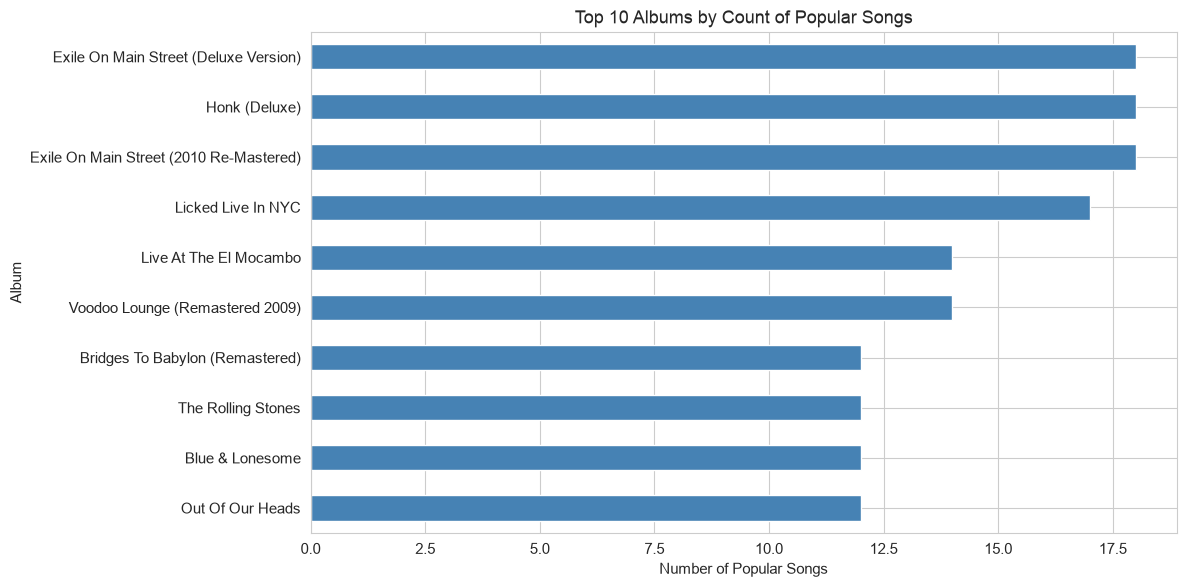

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = album_popular_counts.head(10).sort_values('popular_song_count')
plot_data['popular_song_count'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Popular Songs')
ax.set_ylabel('Album')
ax.set_title('Top 10 Albums by Count of Popular Songs')
plt.tight_layout()
plt.show()

### 3.2 Distribution of Audio Features

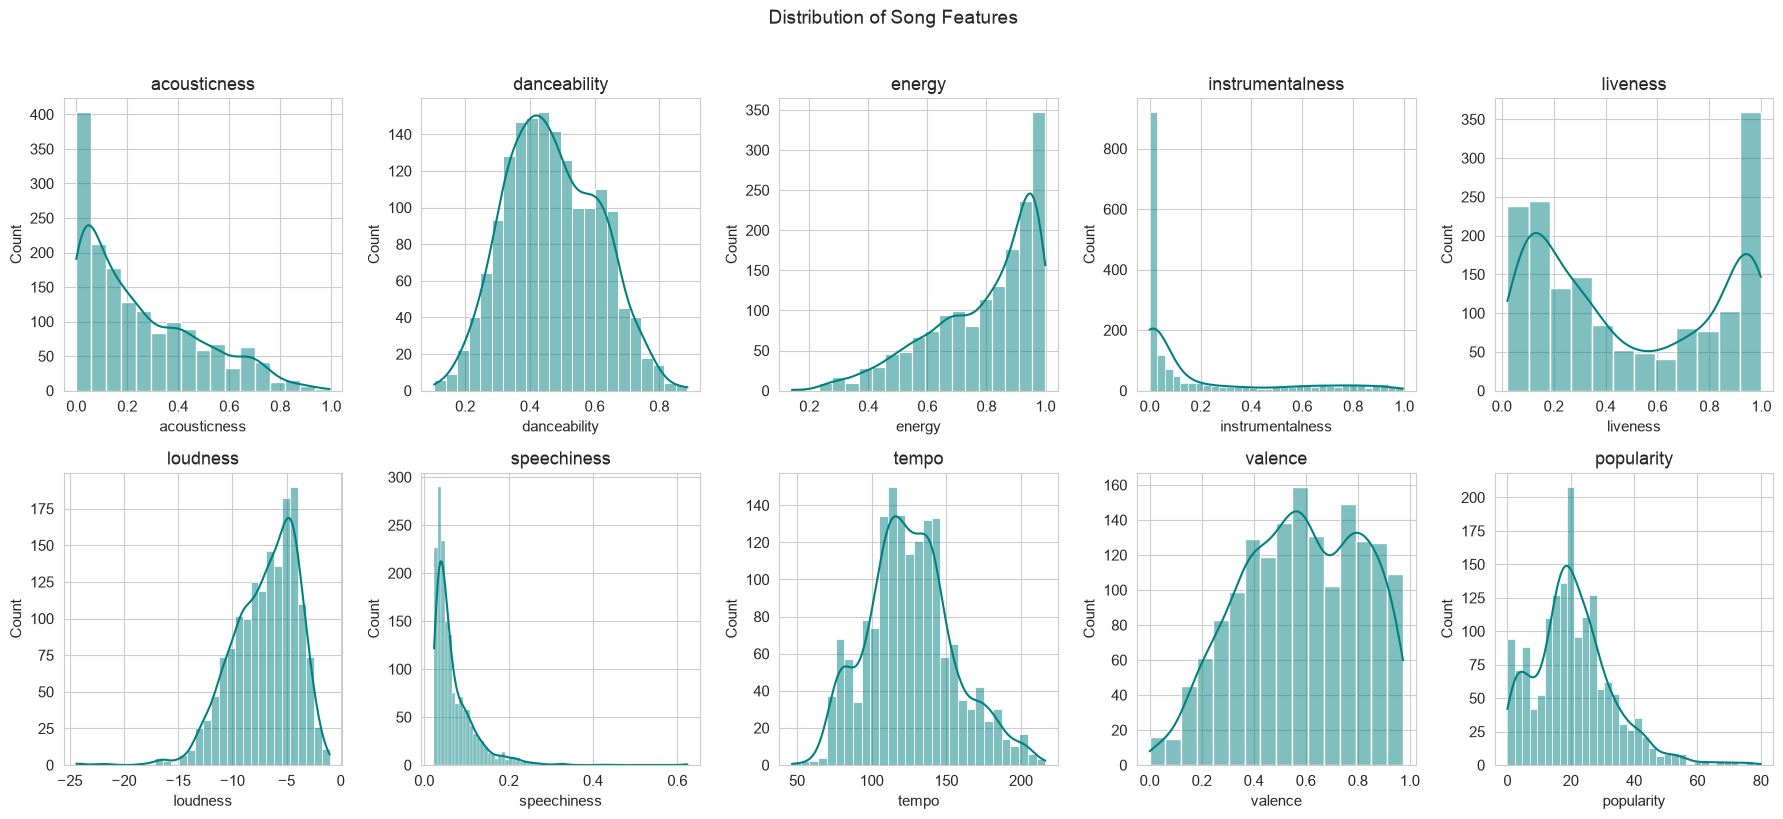

In [8]:
feature_cols = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity'
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col)
plt.suptitle('Distribution of Song Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Correlation Between Features

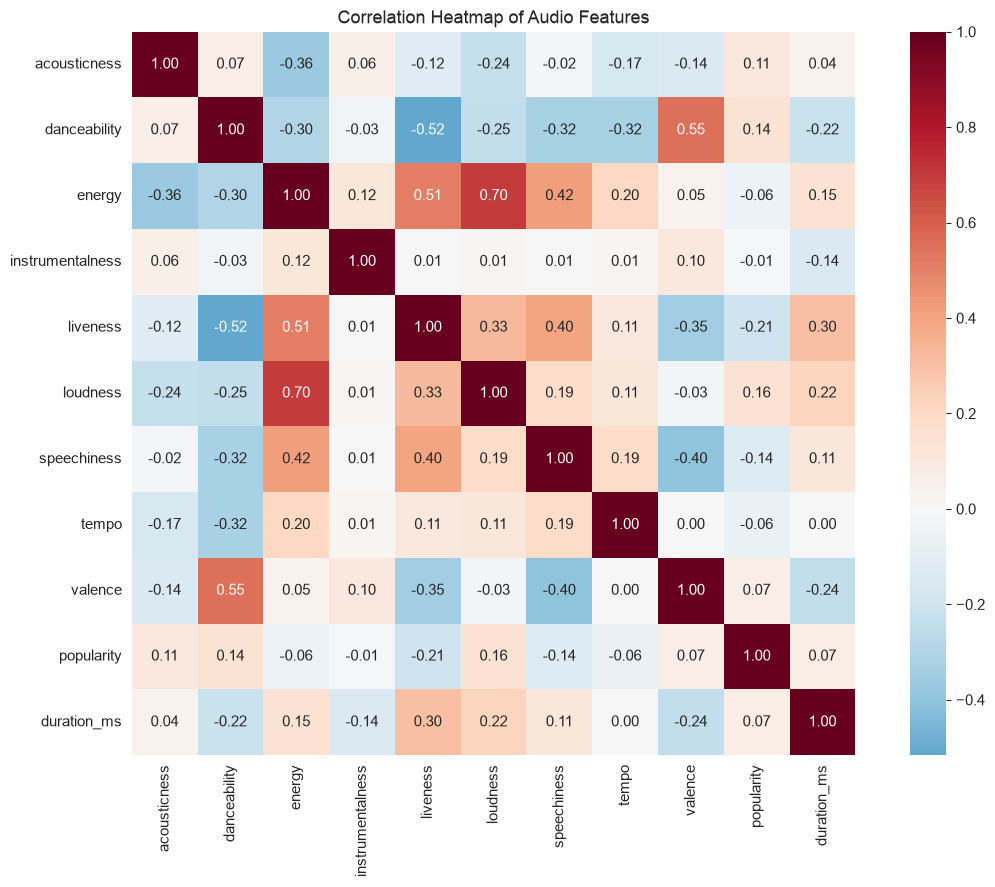

Strongest correlations with popularity:
liveness       0.2058
loudness       0.1563
danceability   0.1412
speechiness    0.1367
acousticness   0.1080
duration_ms    0.0741
valence        0.0653
tempo          0.0611
Name: popularity, dtype: float64


In [9]:
corr = df[feature_cols + ['duration_ms']].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap of Audio Features')
plt.tight_layout()
plt.show()

print('Strongest correlations with popularity:')
print(corr['popularity'].drop('popularity').abs().sort_values(ascending=False).head(8))

### 3.4 Popularity vs Features Over Time

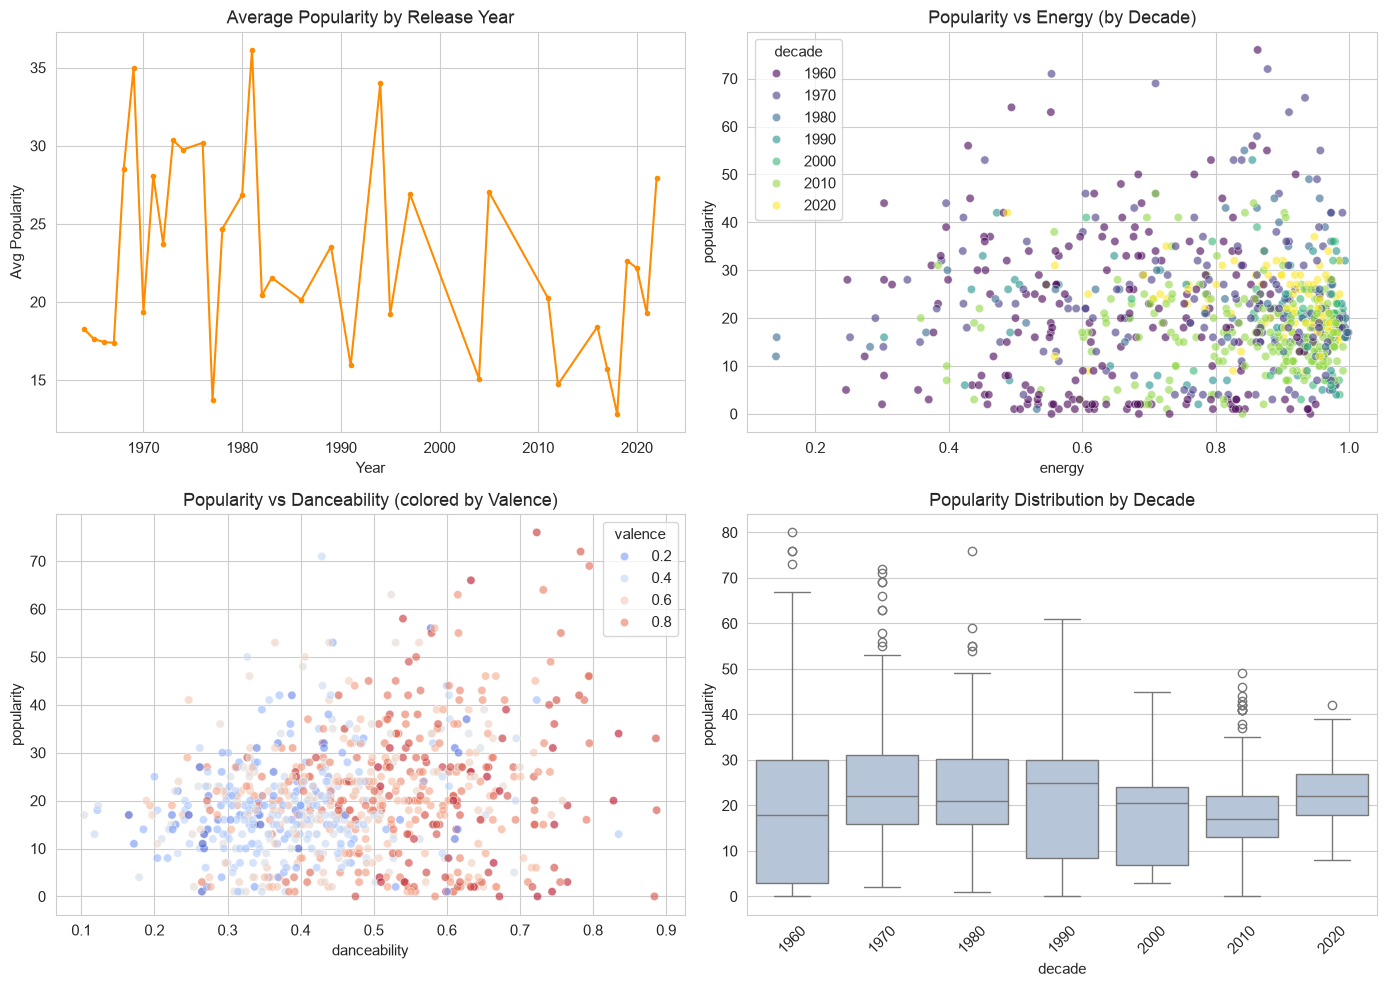

Mean feature values by decade (selected):


,popularity,energy,danceability,acousticness,valence
decade,,,,,
1960,19.4260,0.6620,0.5370,0.2690,0.6380
1970,24.0680,0.7810,0.4840,0.3500,0.6640
1980,25.1330,0.8150,0.5410,0.1770,0.6700
1990,22.2330,0.7820,0.4860,0.2310,0.5420
2000,18.1770,0.8960,0.4020,0.1590,0.4560
2010,17.4630,0.8530,0.4130,0.2000,0.5050
2020,22.3600,0.8990,0.3950,0.2340,0.5010


In [10]:
# Decade buckets for trend analysis
df['decade'] = (df['release_year'] // 10) * 10

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Popularity over years
yearly = df.groupby('release_year')['popularity'].mean()
axes[0, 0].plot(yearly.index, yearly.values, marker='o', markersize=3, color='darkorange')
axes[0, 0].set_title('Average Popularity by Release Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Avg Popularity')

# Energy vs popularity
sns.scatterplot(data=df.sample(min(800, len(df)), random_state=42),
                x='energy', y='popularity', hue='decade', palette='viridis',
                alpha=0.6, ax=axes[0, 1], legend='brief')
axes[0, 1].set_title('Popularity vs Energy (by Decade)')

# Danceability vs popularity
sns.scatterplot(data=df.sample(min(800, len(df)), random_state=42),
                x='danceability', y='popularity', hue='valence',
                palette='coolwarm', alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('Popularity vs Danceability (colored by Valence)')

# Boxplot popularity by decade
sns.boxplot(data=df, x='decade', y='popularity', ax=axes[1, 1], color='lightsteelblue')
axes[1, 1].set_title('Popularity Distribution by Decade')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Mean feature values by decade (selected):')
display(df.groupby('decade')[['popularity', 'energy', 'danceability', 'acousticness', 'valence']].mean().round(3))

**EDA insights (patterns):**
- Energy and loudness tend to move together; acousticness often moves opposite to energy.
- Popularity varies by era — newer releases on Spotify can score higher due to platform effects, not only musical quality.
- Live-heavy tracks often show high `liveness`; studio tracks cluster differently on energy/danceability.
- Valence and danceability help separate “feel-good / danceable” cohorts from darker / less danceable ones.

## 4. Dimensionality Reduction (PCA)

High-dimensional audio features are correlated. PCA compresses them into fewer components that still explain most variance — useful before clustering and for 2D visualization of cohorts.

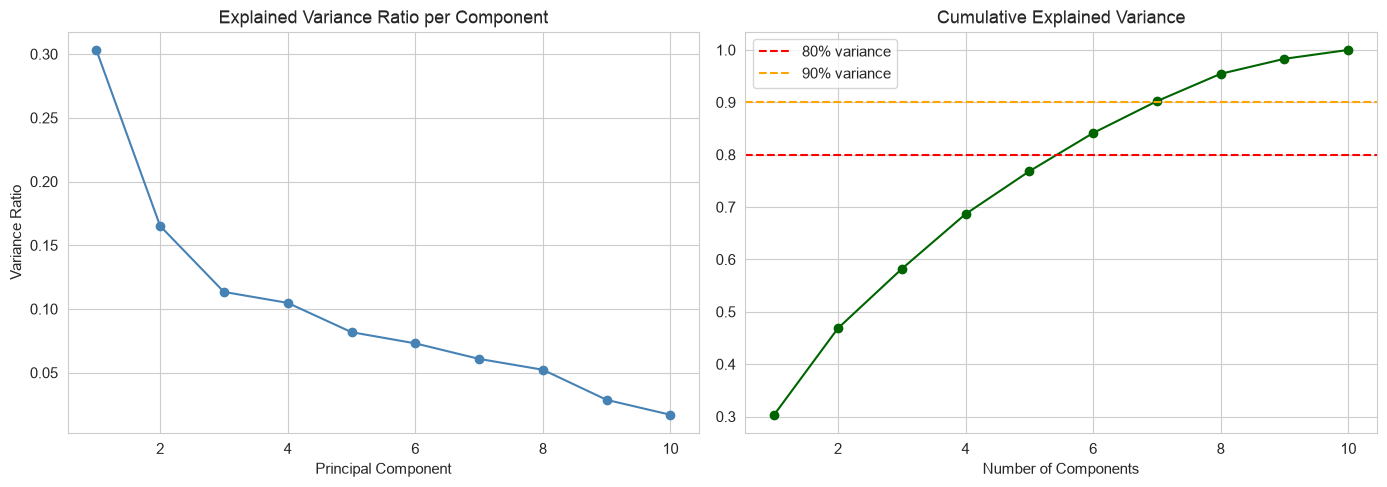

Components for ≥80% variance: 6
Components for ≥90% variance: 7

PC1 loadings (top drivers):
liveness       0.4421
energy         0.4290
danceability   0.4120
loudness       0.3609
speechiness    0.3608
valence        0.2693
dtype: float64


In [11]:
# Features for clustering / PCA (exclude popularity as target-like engagement metric;
# keep core audio descriptors + scaled loudness/tempo)
cluster_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration_ms'
]

X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA().fit(X_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(cumsum) + 1), pca_full.explained_variance_ratio_, 'o-', color='steelblue')
axes[0].set_title('Explained Variance Ratio per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')

axes[1].plot(range(1, len(cumsum) + 1), cumsum, 'o-', color='darkgreen')
axes[1].axhline(0.80, color='red', linestyle='--', label='80% variance')
axes[1].axhline(0.90, color='orange', linestyle='--', label='90% variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].legend()
plt.tight_layout()
plt.show()

n_80 = int(np.argmax(cumsum >= 0.80) + 1)
n_90 = int(np.argmax(cumsum >= 0.90) + 1)
print(f'Components for ≥80% variance: {n_80}')
print(f'Components for ≥90% variance: {n_90}')
print('\nPC1 loadings (top drivers):')
loadings = pd.Series(pca_full.components_[0], index=cluster_features).abs().sort_values(ascending=False)
print(loadings.head(6))

In [12]:
# 2D PCA projection for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)
df['pc1'] = X_pca[:, 0]
df['pc2'] = X_pca[:, 1]
print(f'Variance captured by 2 PCs: {pca_2d.explained_variance_ratio_.sum():.1%}')

Variance captured by 2 PCs: 46.8%


**Why dimensionality reduction matters here:**
1. **Collinearity** — energy/loudness (and similar pairs) inflate distance metrics in clustering.
2. **Noise reduction** — PCA keeps dominant musical structure and drops weak dimensions.
3. **Visualization** — 2–3 PCs let us see whether cohorts separate in feature space.
4. **Efficiency** — fewer dimensions speed up clustering on larger catalogs.

## 5. Cluster Analysis — Finding the Right Number of Clusters

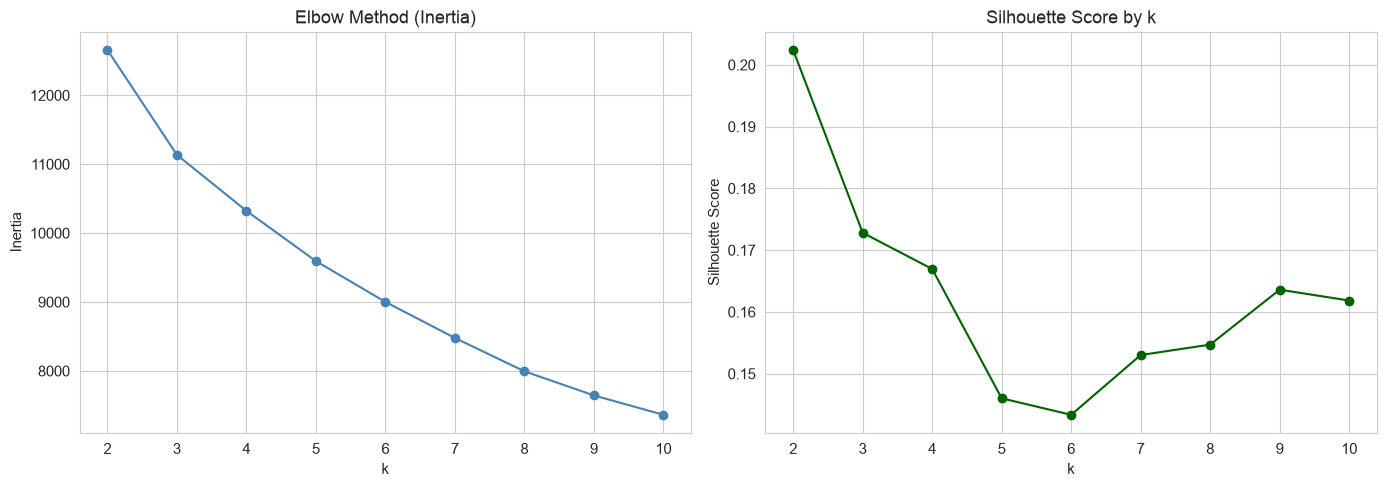

Silhouette scores: {2: 0.202, 3: 0.173, 4: 0.167, 5: 0.146, 6: 0.143, 7: 0.153, 8: 0.155, 9: 0.164, 10: 0.162}
Best k by silhouette: 2


In [13]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 'o-', color='darkgreen')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print('Silhouette scores:', dict(zip(K_range, [round(s, 3) for s in silhouettes])))
print(f'Best k by silhouette: {best_k}')

### 5.1 K-Means Clustering

In [14]:
# Choose k: silhouette optimum, with a practical cohort count (often 4)
OPTIMAL_K = best_k
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means with k={OPTIMAL_K}')
print(df['cluster'].value_counts().sort_index())
print(f'\nSilhouette score: {silhouette_score(X_scaled, df["cluster"]):.3f}')

K-Means with k=2
cluster
0    713
1    897
Name: count, dtype: int64

Silhouette score: 0.202


In [15]:
# Cluster centers in original feature space
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features
)
centers.index = [f'Cluster {i}' for i in range(OPTIMAL_K)]
display(centers.round(3))

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms
Cluster 0,0.1950,0.3720,0.9130,0.1600,0.7940,-5.4580,0.0980,134.9580,0.4790,294479.2930
Cluster 1,0.2950,0.5460,0.6970,0.1670,0.2520,-8.1740,0.0470,119.0270,0.6640,228530.6690


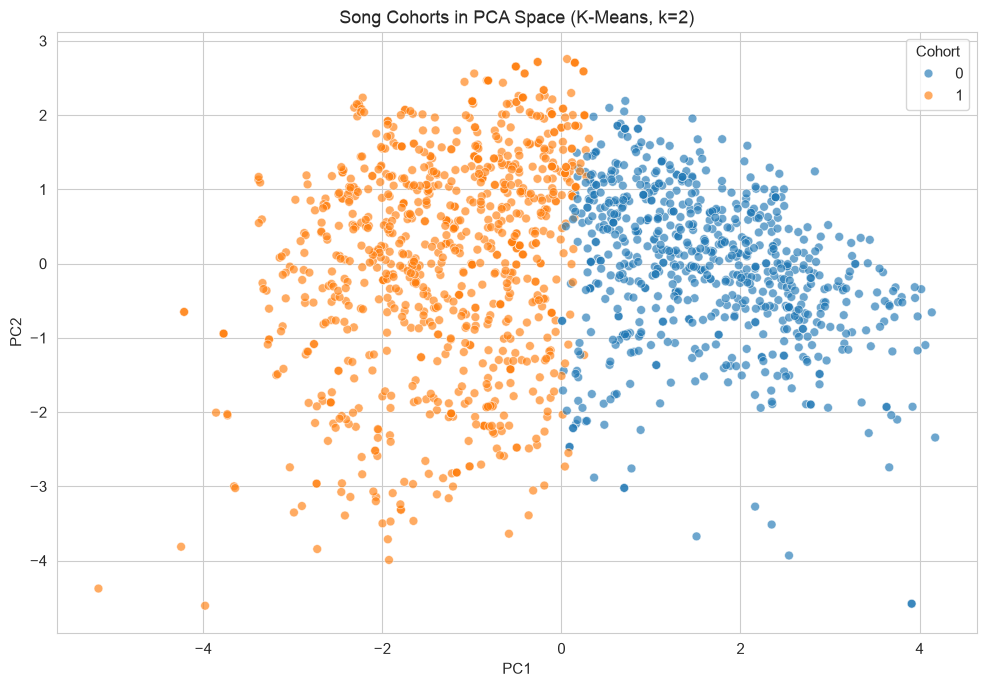

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='pc1', y='pc2', hue='cluster', palette='tab10', alpha=0.65, s=40)
plt.title(f'Song Cohorts in PCA Space (K-Means, k={OPTIMAL_K})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cohort')
plt.tight_layout()
plt.show()

### 5.2 Hierarchical Clustering (comparison)

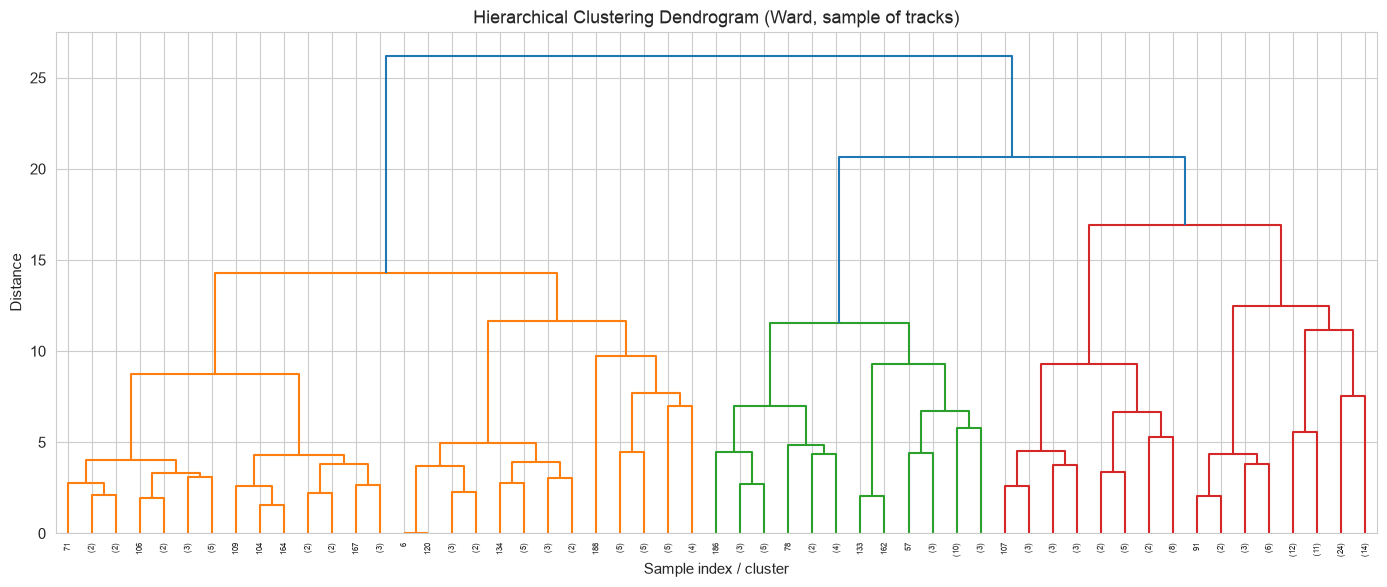

Hierarchical cluster sizes:
cluster_hier
0    973
1    637
Name: count, dtype: int64
Silhouette (hierarchical): 0.156


In [17]:
# Sample for dendrogram readability
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=min(200, len(X_scaled)), replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Ward, sample of tracks)')
plt.xlabel('Sample index / cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df['cluster_hier'] = agg.fit_predict(X_scaled)
print('Hierarchical cluster sizes:')
print(df['cluster_hier'].value_counts().sort_index())
print(f'Silhouette (hierarchical): {silhouette_score(X_scaled, df["cluster_hier"]):.3f}')

## 6. Define Each Cluster (Cohort Profiles)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity,n_songs
cluster,,,,,,,,,,,,
0,0.1950,0.3720,0.9130,0.1600,0.7940,-5.4580,0.0980,134.9580,0.4790,294479.2930,18.3390,713
1,0.2950,0.5460,0.6970,0.1670,0.2520,-8.1740,0.0470,119.0270,0.6640,228530.6690,22.7350,897


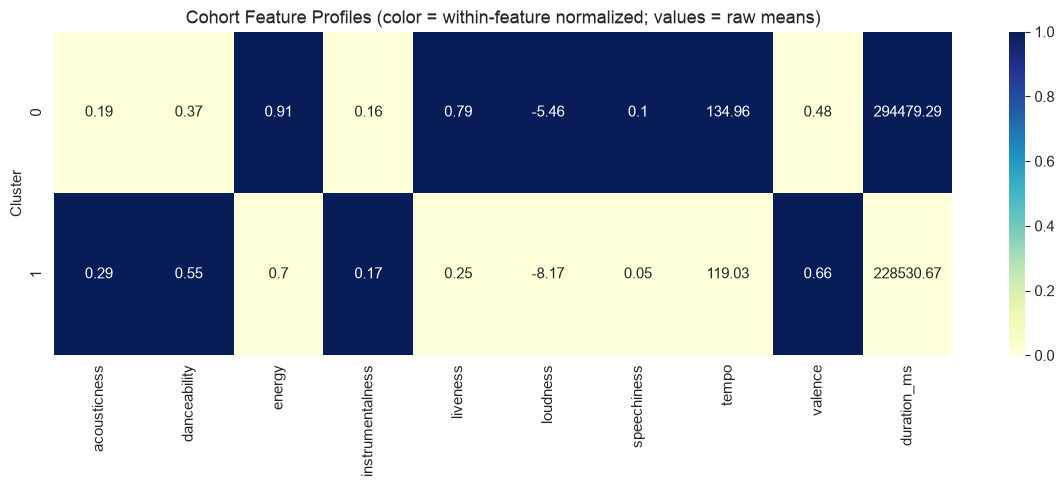

In [18]:
profile = df.groupby('cluster')[cluster_features + ['popularity']].mean()
profile['n_songs'] = df.groupby('cluster').size()
display(profile.round(3))

# Radar-style comparison via normalized heatmap
profile_audio = profile[cluster_features]
profile_norm = (profile_audio - profile_audio.min()) / (profile_audio.max() - profile_audio.min() + 1e-9)
plt.figure(figsize=(12, 5))
sns.heatmap(profile_norm, annot=profile_audio.round(2), fmt='', cmap='YlGnBu')
plt.title('Cohort Feature Profiles (color = within-feature normalized; values = raw means)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [19]:
# Example songs per cohort
print('Sample tracks from each cohort:\n')
for c in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == c].nlargest(3, 'popularity')[['name', 'album', 'popularity', 'energy', 'danceability', 'acousticness', 'liveness']]
    print(f'=== Cluster {c} (n={ (df.cluster==c).sum() }) ===')
    display(subset)

Sample tracks from each cohort:

=== Cluster 0 (n=713) ===


,name,album,popularity,energy,danceability,acousticness,liveness
1094,Loving Cup,Exile On Main Street (Deluxe Version),50,0.8430,0.4710,0.6360,0.7730
1468,The Last Time - Mono Version,Out Of Our Heads,50,0.9200,0.3270,0.1440,0.7740
1121,Sway - 2009 Mix,Sticky Fingers (Remastered),46,0.8950,0.3300,0.2210,0.4080


=== Cluster 1 (n=897) ===


,name,album,popularity,energy,danceability,acousticness,liveness
1403,"Paint It, Black",Aftermath,80,0.7950,0.4640,0.0493,0.3990
862,Start Me Up - Remastered 2009,Tattoo You (2009 Re-Mastered),76,0.9320,0.6310,0.0436,0.0918
1248,Gimme Shelter,Let It Bleed,76,0.6300,0.6340,0.4470,0.1700


In [20]:
# Auto-generate plain-language cohort labels from dominant traits
def label_cluster(row):
    tags = []
    if row['liveness'] > profile['liveness'].median():
        tags.append('Live / Audience')
    if row['acousticness'] > profile['acousticness'].median():
        tags.append('Acoustic')
    if row['energy'] > profile['energy'].median():
        tags.append('High-Energy')
    else:
        tags.append('Mellow')
    if row['danceability'] > profile['danceability'].median():
        tags.append('Danceable')
    if row['instrumentalness'] > profile['instrumentalness'].median():
        tags.append('Instrumental-leaning')
    if row['valence'] > profile['valence'].median():
        tags.append('Upbeat')
    else:
        tags.append('Darker Mood')
    return ' | '.join(tags[:4])

labels = profile.apply(label_cluster, axis=1)
print('Cohort definitions:')
for c, lab in labels.items():
    print(f'  Cluster {c}: {lab}  (n={int(profile.loc[c, "n_songs"])}, avg popularity={profile.loc[c, "popularity"]:.1f})')

Cohort definitions:
  Cluster 0: Live / Audience | High-Energy | Darker Mood  (n=713, avg popularity=18.3)
  Cluster 1: Acoustic | Mellow | Danceable | Instrumental-leaning  (n=897, avg popularity=22.7)


## 7. Summary & Recommendations

1. **Data quality:** Rolling Stones Spotify catalog cleaned; features ready for unsupervised learning.
2. **Album recommendations:** Top 2 albums by count of popular songs (see Section 3.1) are the primary recommendations for general listeners.
3. **Feature patterns:** Energy, loudness, acousticness, danceability, valence, and liveness are the main axes separating song types.
4. **Popularity over time:** Platform-era effects appear in newer releases; musical attributes still drive cohort membership more than popularity alone.
5. **PCA:** A handful of components capture most variance — valuable before clustering and for visualizing cohorts.
6. **Cohorts:** K-Means (validated with silhouette + hierarchical check) produces interpretable song groups (live vs studio, high-energy vs mellow, etc.) that can power playlist / recommendation cohorts.

**Deliverable:** This notebook (`.ipynb`) with EDA, PCA rationale, and defined song cohorts.